# Проект 02 – Разведочный анализ

## 1. Exploratory Data Analysis

**Pandas** — это одна из самых популярных библиотек Python для работы с табличными данными. Она предоставляет удобные 
структуры данных:
* **Series** — одномерный массив с индексами, похожий на колонку в таблице;
* **DataFrame** — двумерная таблица, где каждая колонка может иметь свой тип данных.

С помощью Pandas можно: фильтровать строки и столбцы, группировать данные, агрегировать показатели, объединять таблицы, 
работать с пропущенными значениями и строить простые визуализации. Владение Pandas — базовый и необходимый навык для 
проведения EDA.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Задание 1.1. Загрузка данных
1. Пройди по ссылке на хранилище с датасетом [2025 Kaggle Machine Learning & Data Science Survey](https://disk.360.yandex.ru/d/ATLDXjTVorMf3Q).
3. Скачай CSV-файлы с данными и сохрани их в папку `datasets`.
4. С помощью библиотеки `pandas` загрузи:
   * таблицу с выбором ответов (multiple choice) в переменную `multiple`,
   * таблицу со свободными ответами (free form) `freeform`.
5. Выведи размеры каждой таблицы.
   
> **Важно:** загружать датасеты на Git не нужно.

In [2]:
freeform = pd.read_csv("../assets/project3/2025/freeFormResponses.csv", low_memory=False)

In [3]:
multiple = pd.read_csv("../assets/project3/2025/multipleChoiceResponses.csv", low_memory=False)

In [4]:
freeform.shape

(23860, 35)

In [5]:
multiple.shape

(23860, 395)

In [6]:
schema = pd.read_csv("../assets/project3/2025/SurveySchema.csv", low_memory=False)

### Задание 1.2. Совмещение таблиц
1. Определи общие колонки в таблицах `multiple` и `freeform` и выведи их количество.
2. Создай копию DataFrame `multiple` и сохрани ее в переменную `responses`.
3. Используя метод `.update()`, дополни DataFrame `responses` данными из DataFrame `freeform`.
4. Проверь корректность объединения: выведи количество уникальных значений, включая `NaN`, в колонке `Q1_OTHER_TEXT` для всех трех таблиц (`multiple`, `freeform` и `responses`).

In [7]:
freeform_columns = set(freeform.columns)
multiple_columns = set(multiple.columns)

In [8]:
over_lapper_columns = list(freeform_columns.intersection(multiple_columns))
len(over_lapper_columns)

35

In [9]:
responses = multiple.copy()

In [10]:
responses.shape

(23860, 395)

In [11]:
multiple.shape

(23860, 395)

In [12]:
responses.update(freeform, overwrite=True)

In [13]:
responses.shape

(23860, 395)

In [14]:
multiple["Q1_OTHER_TEXT"].value_counts(dropna=False)

Q1_OTHER_TEXT
-1    23780
42        4
25        4
20        3
14        2
      ...  
31        1
32        1
33        1
35        1
67        1
Name: count, Length: 68, dtype: int64

In [15]:
freeform["Q1_OTHER_TEXT"].value_counts(dropna=False)

Q1_OTHER_TEXT
NaN                          23780
non-binary                       4
Agender                          4
Non-binary                       3
Male                             2
                             ...  
Transgender Female               1
genderless                       1
Nonbinary (born female)          1
bigender                         1
Apache Attack Helicopter         1
Name: count, Length: 68, dtype: int64

In [16]:
responses["Q1_OTHER_TEXT"].value_counts(dropna=False)

Q1_OTHER_TEXT
-1                           23702
42                               4
25                               4
Agender                          4
non-binary                       4
                             ...  
24                               1
shemale                          1
23                               1
22                               1
Apache Attack Helicopter         1
Name: count, Length: 133, dtype: int64

### Задание 1.3. Словарь вопросов
В таблице `responses` первая строка содержит текстовые формулировки вопросов (например: *'What is your gender? — Selected Choice'*, *'What is your age (# years)?'* и т. д.), а сами данные начинаются со второй строки.

1. Создай структуру `name2question`, которая для каждой колонки содержит словарь с ключами `question` и `type`. В ключе `question` хранится текст вопроса, а в ключе `type` — тип таблицы, из которой пришел вопрос: `'multiple'`, `'freeform'` или `'both'` (если колонка есть в обеих таблицах).
```
name2question['Q1']
{'question': 'What is your gender? - Selected Choice', 'source': 'multiple'}
```

2. Выведи значение для вопроса `Q1_OTHER_TEXT` из структуры `name2question`.
3. Удали первую строку из таблицы `responses`.
4. Выведи размерность таблицы `responses` после удаления первой строки.

In [17]:
multiple_questions = multiple.iloc[0].to_dict()
freeform_questions = freeform.iloc[0].to_dict()

name2question = {}

for col_name, question_text in multiple_questions.items():
    name2question[col_name] = {
        'question': question_text,
        'source': 'multiple'
    }

for col_name, question_text in freeform_questions.items():
    if col_name in name2question:
        name2question[col_name]['source'] = 'both'
    else:
        name2question[col_name] = {
            'question': question_text,
            'source': 'freeform'
        }

In [18]:
name2question["Q1_OTHER_TEXT"]

{'question': 'What is your gender? - Prefer to self-describe - Text',
 'source': 'both'}

In [19]:
responses = responses.drop(0)
responses.shape

(23859, 395)

In [20]:
WIP

NameError: name 'WIP' is not defined

### Задание 1.4. Анализ пропущенных значений

Работа с пропущенными значениями — важная часть EDA.

1. Используя метод `.isna()`, посчитай количество пропущенных значений в каждой колонке таблицы `responses`.
2. Отсортируй результат по убыванию и выведи топ-10 колонок с наибольшим количеством пропусков.
3. Вычисли долю пропущенных значений (в процентах) для каждой колонки.
4. Определи, сколько колонок имеют более 50% пропущенных значений.
5. Выведи количество строк, в которых отсутствуют данные хотя бы в одной колонке.

In [18]:
missing_counts = responses.isna().sum()
missing_counts

Time from Start to Finish (seconds)        0
Q1                                         0
Q1_OTHER_TEXT                              0
Q2                                         0
Q3                                         0
                                       ...  
Q50_Part_5                             20290
Q50_Part_6                             22800
Q50_Part_7                             21359
Q50_Part_8                             23339
Q50_OTHER_TEXT                             0
Length: 395, dtype: int64

In [24]:
top_20_missing = missing_counts.sort_values(ascending=False).head(20)
print("Топ-20 колонок с наибольшим количеством пропусков:")
print(top_20_missing)

Топ-20 колонок с наибольшим количеством пропусков:
Q21_Part_12    23859
Q29_Part_27    23859
Q14_Part_10    23859
Q27_Part_19    23859
Q38_Part_20    23859
Q38_Part_19    23859
Q19_Part_18    23859
Q28_Part_42    23859
Q16_Part_17    23859
Q36_Part_12    23859
Q13_Part_14    23859
Q30_Part_24    23859
Q28_Part_22    23842
Q28_Part_24    23828
Q29_Part_16    23821
Q29_Part_25    23806
Q29_Part_14    23800
Q29_Part_24    23798
Q30_Part_15    23798
Q29_Part_23    23793
dtype: int64


In [25]:
missing_percentage = (missing_counts / len(responses)) * 100
print("Доля пропущенных значений (в процентах) для каждой колонки:")
print(missing_percentage)
print()

Доля пропущенных значений (в процентах) для каждой колонки:
Time from Start to Finish (seconds)     0.000000
Q1                                      0.000000
Q1_OTHER_TEXT                           0.000000
Q2                                      0.000000
Q3                                      0.000000
                                         ...    
Q50_Part_5                             85.041284
Q50_Part_6                             95.561423
Q50_Part_7                             89.521774
Q50_Part_8                             97.820529
Q50_OTHER_TEXT                          0.000000
Length: 395, dtype: float64



In [26]:
columns_over_50_percent = (missing_percentage > 50).sum()
print(f"Количество колонок с более чем 50% пропущенных значений: {columns_over_50_percent}")
print()

Количество колонок с более чем 50% пропущенных значений: 314



In [27]:
rows_with_missing = responses.isna().any(axis=1).sum()
print(f"Количество строк с хотя бы одним пропуском: {rows_with_missing}")

Количество строк с хотя бы одним пропуском: 23859


In [34]:
responses.columns[responses.isna().sum() == len(responses)]

Index(['Q13_Part_14', 'Q14_Part_10', 'Q16_Part_17', 'Q19_Part_18',
       'Q21_Part_12', 'Q27_Part_19', 'Q28_Part_42', 'Q29_Part_27',
       'Q30_Part_24', 'Q36_Part_12', 'Q38_Part_19', 'Q38_Part_20'],
      dtype='object')

In [36]:
responses["Q13_Part_14"].isna().sum()

23859

### Задание 1.4. Очистка респондентов

В данных есть информация о времени заполнения опроса. Логично предположить, что если респондент отвечал **слишком быстро** или, наоборот, **слишком долго**, такие ответы могут быть недостоверными. Для очистки данных воспользуемся методом выявления выбросов на основе **box plot**.

**Box plot (ящик с усами)** — это способ визуализации распределения данных. Внутри прямоугольника (ящика) находятся значения от 1-го до 3-го квартиля (Q1 и Q3), линия внутри — это медиана. «Усы» обычно определяются через **интерквартильный размах (IQR)**, который равен:

$$IQR = Q3 - Q1$$
Значения ниже $Q1 - 1.5 \times IQR$ и выше $Q3 + 1.5 \times IQR$ считаются выбросами.

1. Построй box plot для времени заполнения опроса. Ограничь ось **X** от 0 до 5000 секунд.
2. Рассчитай интерквартильный размах (IQR).
3. Выведи нижнюю и верхнюю границы интервала для выявления выбросов.
4. Так как нижняя граница получилась отрицательной, будем априорно считать минимальное адекватное время заполнения равным **2 минутам (120 секунд)**.
5. Отфильтруй DataFrame, оставив только респондентов с временем заполнения от 120 секунд до верхней границы.
6. Выведи размерность очищенного датасета.

In [18]:
responses["Time from Start to Finish (seconds)"] = responses["Time from Start to Finish (seconds)"].astype(int)

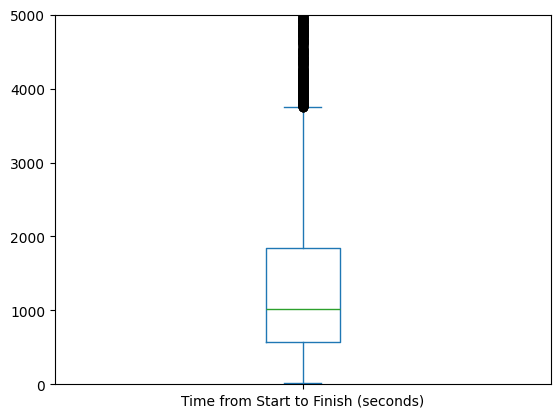

In [19]:
responses["Time from Start to Finish (seconds)"].plot.box()
plt.ylim(0, 5000)
plt.show();

In [20]:
Q1 = np.percentile(responses["Time from Start to Finish (seconds)"], 25)
Q3 = np.percentile(responses["Time from Start to Finish (seconds)"], 75)
IQR = Q3 - Q1
print(IQR)

1272.0


In [21]:
upper = Q3+1.5*IQR
print("Upper Bound:", upper)

lower = Q1-1.5*IQR
print("Lower Bound:", lower)

Upper Bound: 3750.0
Lower Bound: -1338.0


In [22]:
responses = responses[
    (responses["Time from Start to Finish (seconds)"] < upper) & 
    (responses["Time from Start to Finish (seconds)"] > 120)
]

In [23]:
responses.shape

(18696, 395)

### Задание 1.5. Не популярный гендер
Обработай результаты опроса по вопросу `What is your gender?`:
1. Объедини ответы из обеих колонок
2. Удали у всех значений ведущие и завершающие пробелы
3. Приведи все ответы к нижнему регистру
4. Удали ответы, содержащие числа
5. Выведи **топ-6 самых популярных** вариантов ответа

In [24]:
name2question["Q1"]

'What is your gender? - Selected Choice'

In [25]:
name2question["Q1_OTHER_TEXT"]

'What is your gender? - Prefer to self-describe - Text'

In [26]:
q1_res = responses["Q1"].str.lower().str.strip().value_counts()
mask = q1_res.index.astype(str).str.contains(r"\d")
q1_res = q1_res[~mask]

q1_res_text = responses["Q1_OTHER_TEXT"].str.lower().str.strip().value_counts()
mask = q1_res_text.index.astype(str).str.contains(r"\d")
q1_res_text = q1_res_text[~mask]

In [27]:
a = pd.concat([q1_res, q1_res_text])

In [28]:
a.sort_values(ascending=False).index

Index(['male', 'female', 'prefer not to say', 'prefer to self-describe',
       'attack helicopter', 'non-binary', 'agender', 'female', 'nonbinary',
       'male', 'transgender', 'transgender female', 'human', 'kaggle',
       'a little sunshine. :)', 'non binary', 'm', 'unclear', 'ai',
       'male and female are sexes not gender. gender is a regressive set of stereotypes associated with our sex. ask what sex we are for demographic purposes, if that is what is important.',
       'my sex is male (no idea about "gender")', 'bot', 'mard',
       'hetero flexible', 'no binary', 'nunya', 'shemale', 'barn owl',
       'gelatinous blob', 'fhjdfjhdfhj', 'apache helicopter',
       'male but asking this at the begining of surveys is going to cause priming and distort your answers. google it. 😀',
       'gaseous', 'trollogender', 'megatron', 'bigender', 'testosterone',
       'neutrois', 'bisexual', 'helicopter', 'jedi', 'surly tomato',
       'baba yaga', 'transgender-fluid transracial black 

In [29]:
responses.to_csv("../assets/project4/kaggle_survey_2025_responses_v1.csv")

In [30]:
with open("../assets/project4/name2question.json", 'w') as fout:
    json.dump(name2question, fout, indent=4)